In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import nibabel as nib
from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.plotting import plot_design_matrix
import matplotlib.pyplot as plt

sub = "sub-P10"
ses = "ses-05"

events_file = Path("data/preprocessed/relabeled_events") / f"{sub}_{ses}_task-viewing_run-01_events_memory_labels.tsv"
func_dir = Path("data/fmriprep_output") / sub / ses / "func"
confounds_file = func_dir / f"{sub}_{ses}_task-viewing_run-01_desc-confounds_timeseries.tsv"
bold_file = func_dir / f"{sub}_{ses}_task-viewing_run-01_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz"
meta_file = func_dir / f"{sub}_{ses}_task-viewing_run-01_space-MNI152NLin2009cAsym_desc-preproc_bold.json"

events = pd.read_csv(events_file, sep="\t")
confounds = pd.read_csv(confounds_file, sep="\t")
bold_img = nib.load(str(bold_file))

print("Events:", events.shape)
print("Confounds:", confounds.shape)
print("BOLD:", bold_img.shape)
print(events["trial_type_memory"].value_counts())
events.head()

Events: (384, 9)
Confounds: (1994, 851)
BOLD: (62, 77, 66, 1994)
trial_type_memory
other                               312
irrelevant_seen_schema_week          30
irrelevant_seen_other_wrong_week     24
irrelevant_seen_true_week            18
Name: count, dtype: int64


,onset,duration,event,button_pressed,answer,HumanAppearOnThe,reaction_time,memory_label,trial_type_memory
0,4.632,3.034,maya_3_e3_6_r_h_v1_old.jpg,1,2.0,Right,0.922,NaN,other
1,10.815,3.017,wealth_5_e3_7_nr_o_v1_old.jpg,1,1.0,Right,0.597,other_wrong_week,irrelevant_seen_other_wrong_week
2,17.065,3.017,pirate_6_e2_13_r_h_v1_old.jpg,1,2.0,Right,0.490,NaN,other
3,23.599,3.016,viking_11_new.jpg,1,2.0,Right,0.452,NaN,other
4,29.499,3.016,pirate_7_e3_1_nr_h_v1_old.jpg,1,2.0,Right,0.391,other_wrong_week,irrelevant_seen_other_wrong_week


In [2]:
# Minimal events table for Nilearn
glm_events = events[["onset", "duration", "trial_type_memory"]].copy()
glm_events = glm_events.rename(columns={"trial_type_memory": "trial_type"})

# Optional: remove "other" if you do not want to model it explicitly
# For now keep it, so all task events are modeled.
print(glm_events["trial_type"].value_counts())

glm_events.head()

trial_type
other                               312
irrelevant_seen_schema_week          30
irrelevant_seen_other_wrong_week     24
irrelevant_seen_true_week            18
Name: count, dtype: int64


,onset,duration,trial_type
0,4.632,3.034,other
1,10.815,3.017,irrelevant_seen_other_wrong_week
2,17.065,3.017,other
3,23.599,3.016,other
4,29.499,3.016,irrelevant_seen_other_wrong_week


Design matrix shape: (1994, 73)
['irrelevant_seen_other_wrong_week', 'irrelevant_seen_other_wrong_week_derivative', 'irrelevant_seen_other_wrong_week_dispersion', 'irrelevant_seen_schema_week', 'irrelevant_seen_schema_week_derivative', 'irrelevant_seen_schema_week_dispersion', 'irrelevant_seen_true_week', 'irrelevant_seen_true_week_derivative', 'irrelevant_seen_true_week_dispersion']


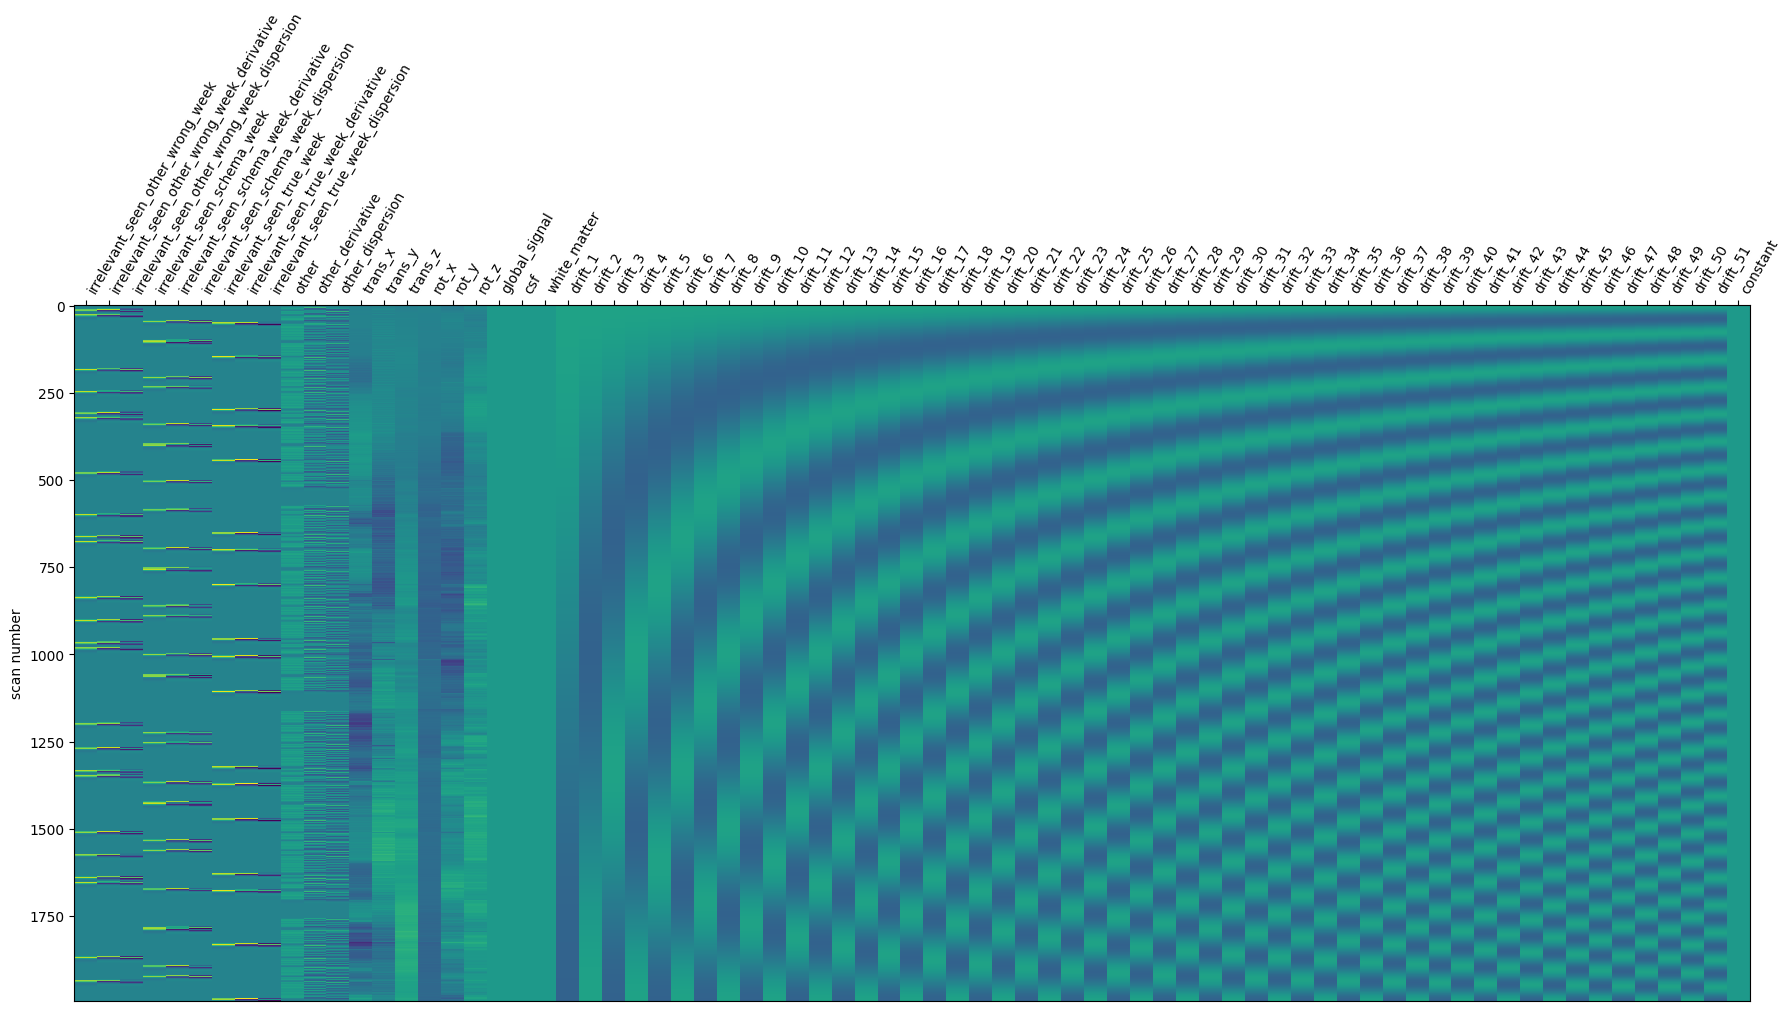

In [3]:
import json

with open(meta_file, "r") as f:
    metadata = json.load(f)

tr = metadata["RepetitionTime"]
n_scans = bold_img.shape[-1]
frame_times = np.arange(n_scans) * tr

confound_cols = ["trans_x", "trans_y", "trans_z", "rot_x", "rot_y", "rot_z", "global_signal", "csf", "white_matter"]
confound_cols = [c for c in confound_cols if c in confounds.columns]
add_regs = confounds[confound_cols].fillna(0)

design_matrix = make_first_level_design_matrix(
    frame_times,
    glm_events,
    hrf_model="spm + derivative + dispersion",
    drift_model="cosine",
    high_pass=0.01,
    add_regs=add_regs,
    add_reg_names=add_regs.columns.tolist(),
)

print("Design matrix shape:", design_matrix.shape)
print([c for c in design_matrix.columns if "irrelevant_seen" in c])

plot_design_matrix(design_matrix)
plt.show()

In [4]:
from nilearn.glm.first_level import FirstLevelModel
from nilearn import datasets, image
import nibabel as nib

# Create a gray matter mask in MNI space, resampled to functional image
gm_mask = datasets.load_mni152_gm_mask(resolution=2, threshold=0.2, n_iter=2)
gm_mask_resampled = image.resample_to_img(
    gm_mask,
    bold_img,
    interpolation="nearest",
    force_resample=True,
    copy_header=True,
)

# Fit first-level model for this single session
fmri_glm = FirstLevelModel(
    mask_img=gm_mask_resampled,
    smoothing_fwhm=5,
    n_jobs=-1,
)

fmri_glm = fmri_glm.fit(
    bold_img,
    design_matrices=design_matrix,
)

print("GLM fitted.")

GLM fitted.


In [5]:
columns = design_matrix.columns.tolist()

contrast_vec = np.zeros(len(columns))

for i, col in enumerate(columns):
    if col == "irrelevant_seen_true_week":
        contrast_vec[i] = 1
    elif col == "irrelevant_seen_schema_week":
        contrast_vec[i] = -1

zmap_true_vs_schema = fmri_glm.compute_contrast(
    contrast_vec,
    output_type="z_score",
)

print("Contrast computed.")

Contrast computed.


/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



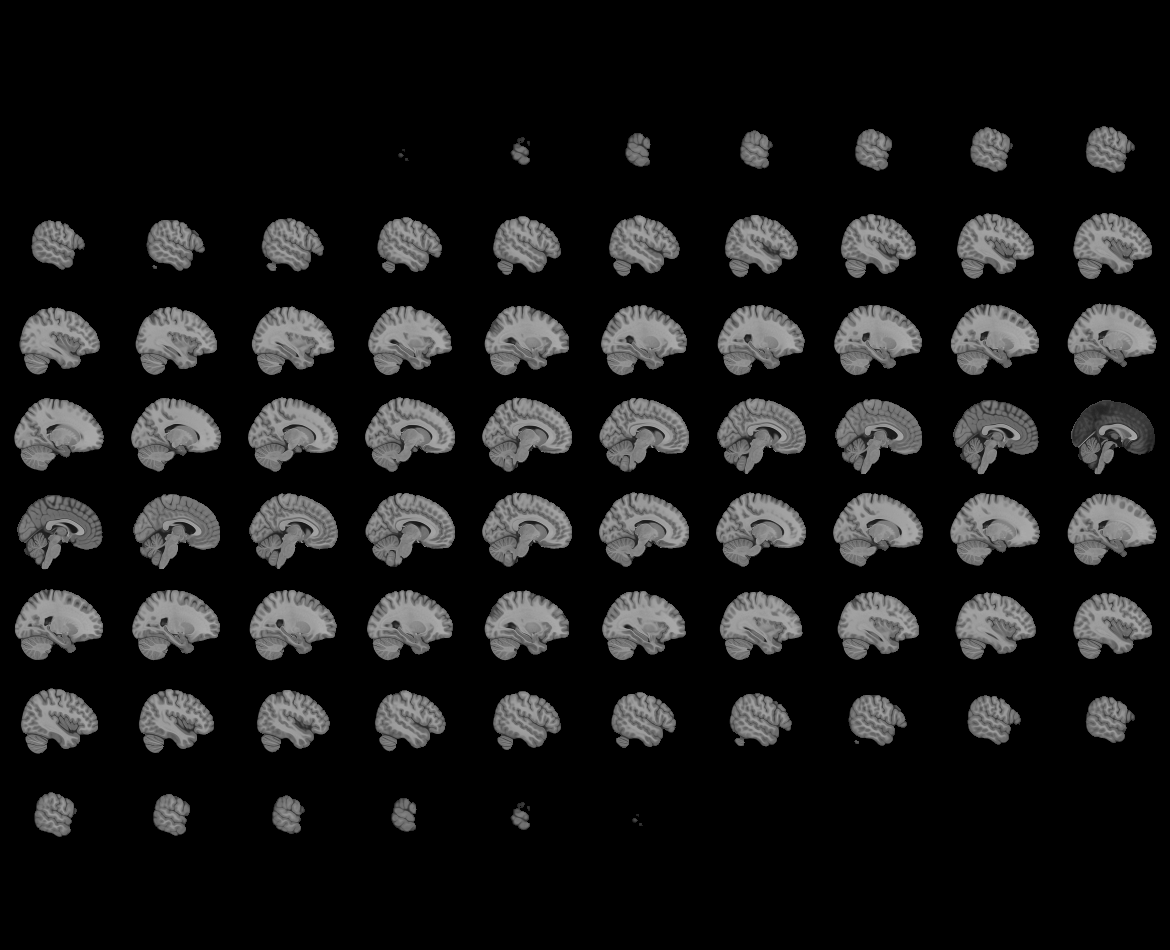
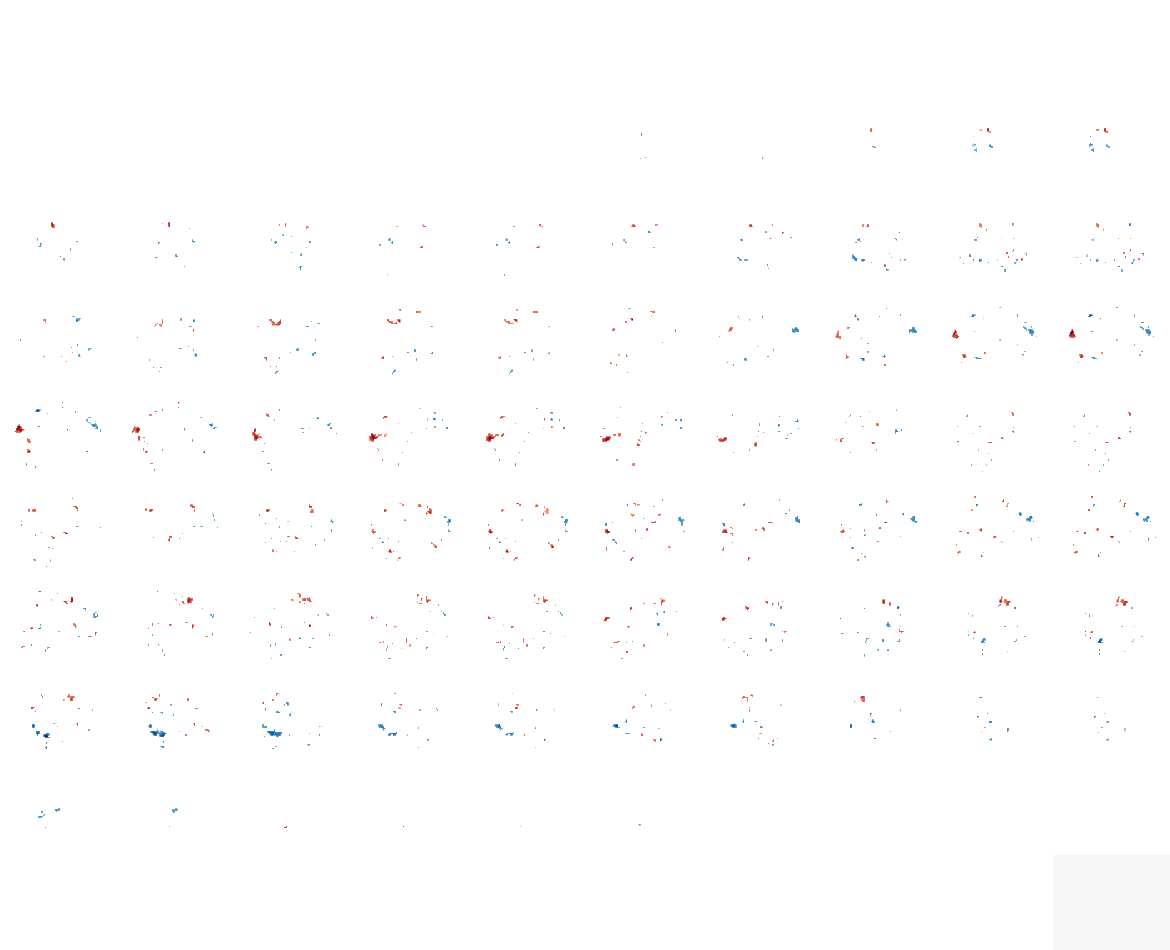

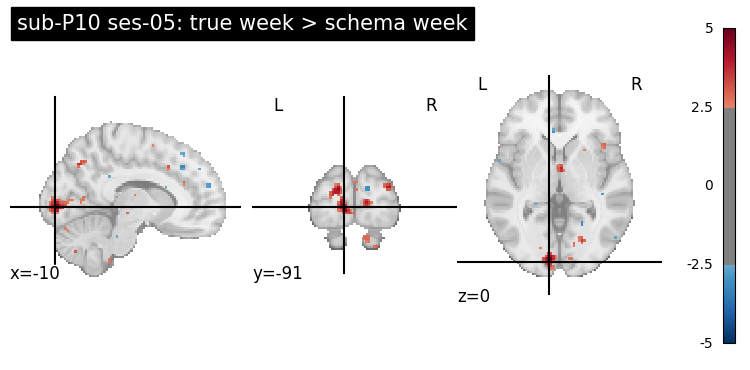

In [6]:
from nilearn import plotting

plotting.plot_stat_map(
    zmap_true_vs_schema,
    threshold=2.5,
    display_mode="ortho",
    title=f"{sub} {ses}: true week > schema week",
)

plotting.view_img(
    zmap_true_vs_schema,
    threshold=2.5,
    title=f"{sub} {ses}: true week > schema week",
)